In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Yes I'm using both seaborn and matplotlib directly
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn import tree
import numpy as np

In [2]:
df = pd.read_csv("data/anderson_lab_protist_data.csv")

df = df[df['prey'] == "paramecium"]

df.dtypes

number.bottles       int64
media                  str
productivity       float64
year                 int64
prey                   str
predator               str
day                  int64
bottle                 str
structure              str
network.syn.lap    float64
bottle.number        int64
replicate              str
connectivity         int64
nghbr.connect      float64
pred.density       float64
prey.density       float64
ln.pred            float64
ln.prey            float64
pred.oc              int64
prey.oc              int64
volume.L           float64
dtype: object

[Text(0.5, 1.0, 'Density Measurements (individuals per ML fluid)'),
 Text(0, 0.5, 'Paramecium (prey)'),
 Text(0.5, 0, 'Didinium (predator)')]

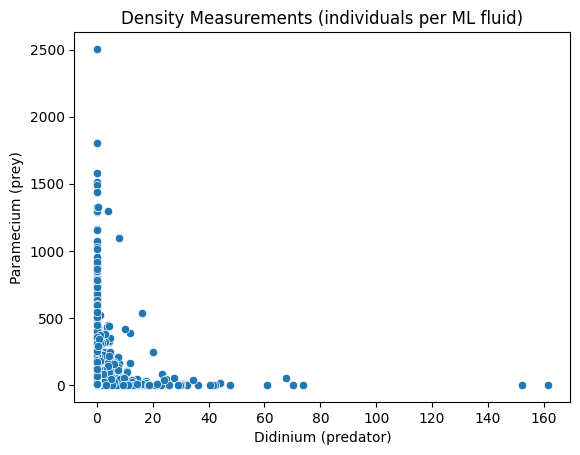

In [3]:
ax = sns.scatterplot(data=df, y="prey.density", x="pred.density")
ax.set(title="Density Measurements (individuals per ML fluid)", ylabel="Paramecium (prey)", xlabel="Didinium (predator)")

In [4]:
model = RandomForestRegressor(random_state=42, max_depth=3)


X = df.select_dtypes(include=[np.number]).drop(columns=['prey.density', 'ln.pred', 'ln.prey', 'pred.oc', 'prey.oc', 'bottle.number'])
# We're trying to predict prey density, so we decided not to include columns that are transformations of the dataset or entirely unrelated to density counts
y = df['prey.density']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)
mse = root_mean_squared_error(y_test, predictions)

pd.DataFrame([mse, df['prey.density'].std()])

,0
0,120.907732
1,138.002882


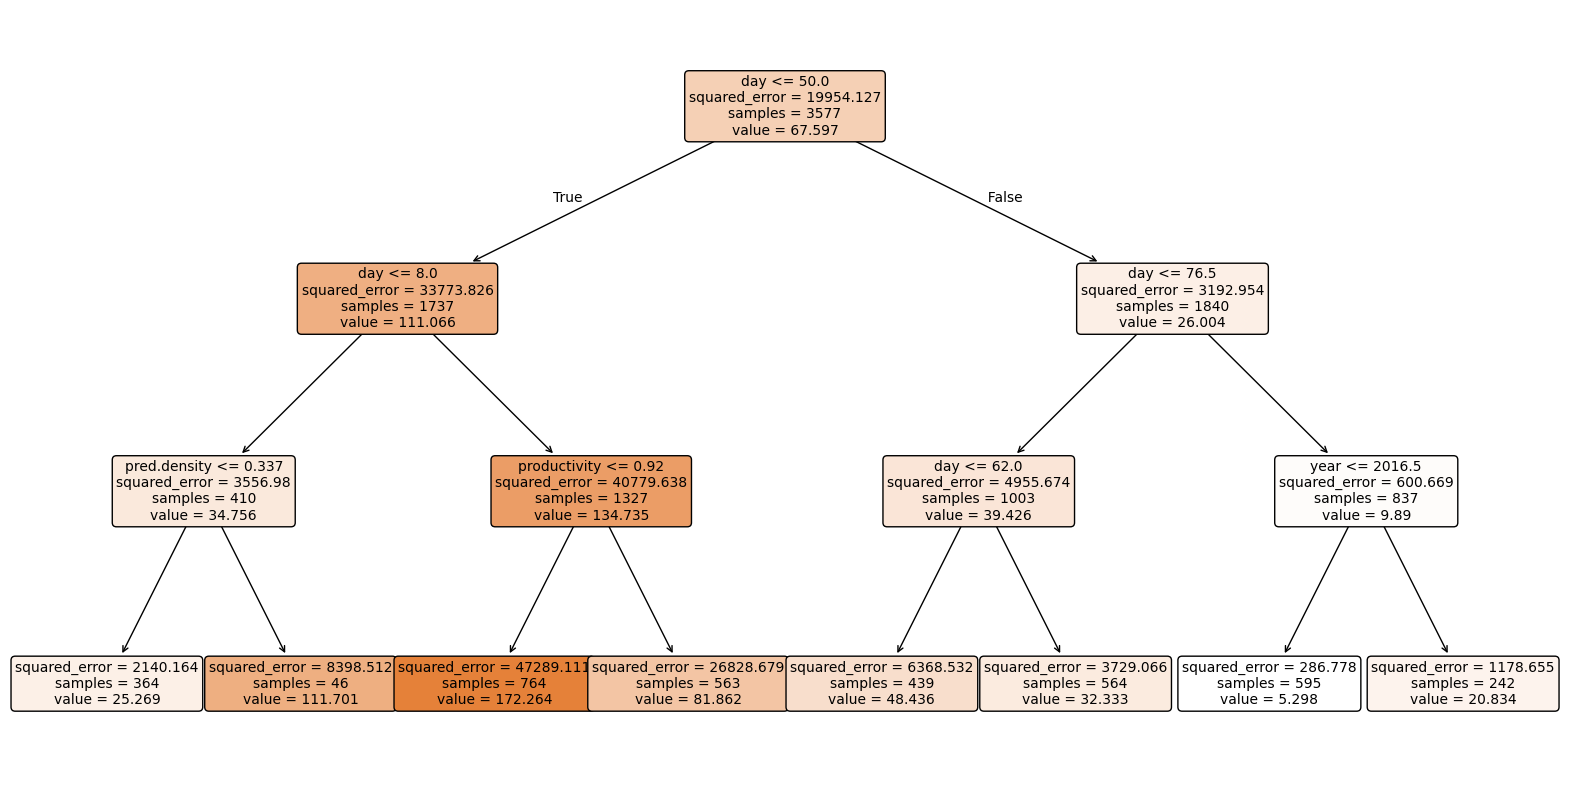

In [ ]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    model.estimators_[0], 
    feature_names=X.columns, 
    filled=True, 
    rounded=True,
    fontsize=10
)

plt.show()